# Movie Rating Prediction
# Objective

The objective of this project is to build a machine learning model that predicts movie ratings based on features such as genre, director, actors, duration, votes, and year using regression techniques.

# 1. Import Libraries

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


# 2. Load Dataset

In [116]:
df=pd.read_csv("/kaggle/input/datasets/ramsaitirumanadham/movie-ratings/IMDb Movies India.csv",encoding='latin')

# 3. Data Exploration


In [117]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [118]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [120]:
df.tail()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN
15508,Zulm-O-Sitam,(1998),130 min,"Action, Drama",6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [121]:
df.shape

(15509, 10)

# 4. Handle missing values:

In [122]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [123]:
df = df.dropna(subset=['Rating'])

# 5. Clean Year, Duration, Votes

In [124]:
df['Year']
df['Year'].astype(str).str.extract(r'(\d{4})',expand=False)
df['Year']=pd.to_numeric(df['Year'],errors='coerce')

In [125]:
df['Duration']
df['Duration'].astype(str).str.extract(r'(\d+)',expand=False)
df['Duration']=pd.to_numeric(df['Duration'],errors='coerce')

In [126]:
df['Votes']=df['Votes'].astype(str).str.replace(',','')
df['Votes']=pd.to_numeric(df['Votes'],errors='coerce')

# 6. Fill Missing Values

In [127]:
df.fillna({
    'Year':df['Year'].median(),'Duration':df['Duration'].median(),'Votes':df['Votes'].median()
},inplace=True)

In [128]:
text_cols=['Genre','Director','Actor 1','Actor 2','Actor 3','Name']
for col in text_cols:
    df[col]=df[col].fillna("Unknown")

# 7. Data Visualization

* **Rating Distribution**

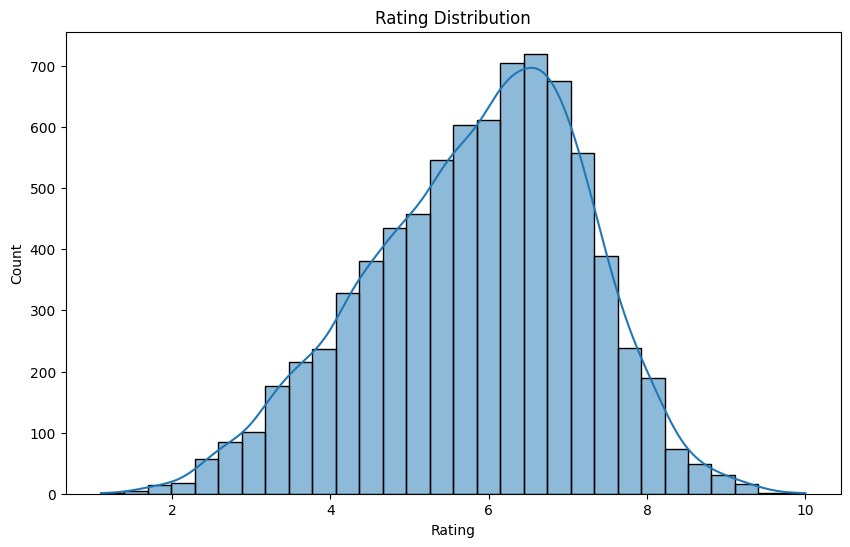

In [129]:
plt.figure(figsize=(10,6))
sns.histplot(df['Rating'],bins=30,kde=True)
plt.title("Rating Distribution")
plt.show()

* **Top Genres**

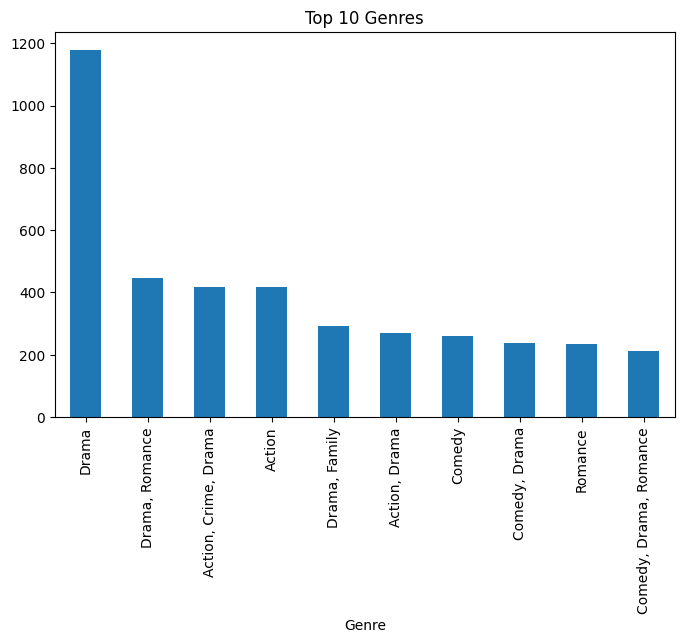

In [130]:
plt.figure(figsize=(8,5))
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.show()

* **Rating vs Votes**

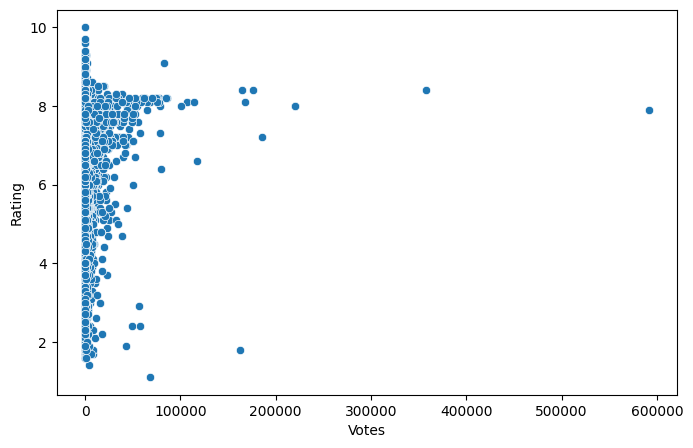

In [131]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Votes',y='Rating',data=df)
plt.show()

* **Correlation Heatmap**

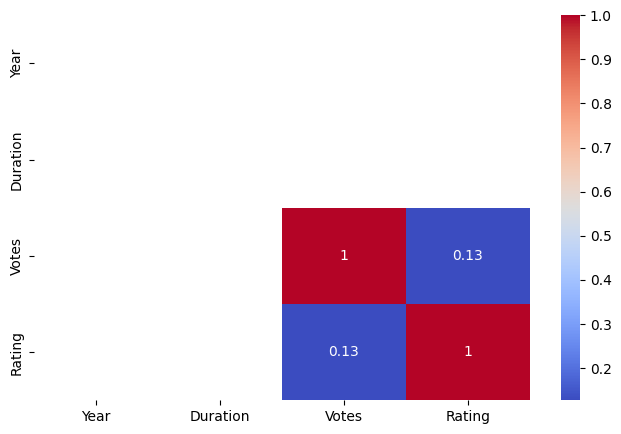

In [132]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Year','Duration','Votes','Rating']].corr(),annot=True,cmap='coolwarm')
plt.show()

# 8. Feature Selection & Encoding

In [133]:
X=df[['Genre','Director','Actor 1','Actor 2','Actor 3','Year','Duration','Votes','Name']].copy()
y=df['Rating']

In [134]:
cat_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Name']
for col in cat_cols:
    freq = X[col].value_counts()
    X[col] = X[col].map(freq)

# 9. Train-test Split

In [135]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                              test_size=0.2,
                                              random_state=42)

# 10. Train The Model

In [136]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

# 11. Make Predictions

In [137]:
y_pred=model.predict(X_test)

# 12. Evaluation

* MAE
* RMSE
* R² Score


In [138]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 0.9806772409636515


In [139]:
rmse=mean_squared_error(y_test,y_pred)
print("RMSE:",rmse)

RMSE: 1.5390991820897433


In [140]:
r2=r2_score(y_test,y_pred)
print("R² Score:",r2)

R² Score: 0.17214683864982294


# 13. Feature Importance

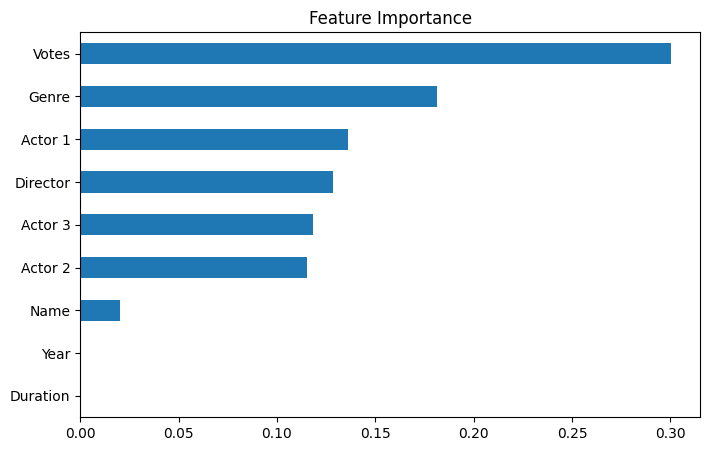

In [141]:
importance =pd.Series(
    model.feature_importances_,index=X.columns
)
importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Feature Importance")
plt.show()

# 14. Evaluation Metric Values

In [142]:
print("Model Performance")
print("----------------")
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))

Model Performance
----------------
MAE: 0.9806772409636515
RMSE: 1.2406043616277282
R2 Score: 0.17214683864982294


# 15. Actual vs Predicted values

In [143]:
results=pd.DataFrame({
    'Actual Rating':y_test.values,
    'Predicted Rating':y_pred
})
results.head(10)

,Actual Rating,Predicted Rating
0,3.3,4.684667
1,5.3,4.268333
2,5.7,5.310000
3,7.2,6.524333
4,3.5,5.582133
5,7.2,6.086000
6,3.8,5.038667
7,6.9,7.264667
8,5.2,6.223000
9,7.4,5.474000


In [144]:
print(X_train.shape)

(6335, 9)


# Conclusion

A Random Forest Regression model was developed to predict movie ratings. After data preprocessing and model training, the model was evaluated using MAE, RMSE, and R² Score, demonstrating effective prediction performance.